# Modules

In [40]:
# +------------------------------------------------------------------------+
# |                                                                        |  
# |                        Load Python modules                             |                        
# |                                                                        | 
# +------------------------------------------------------------------------+

from math import * 
import numpy as np 
from SplineBraidModel_V4_functionFile import *
from scipy.interpolate import splrep, BSpline
import matplotlib.pyplot as plt 
from prettytable import PrettyTable
from stl import mesh 
import os 
import time 
from rich.console import Console 
from rich.table import Table
from rich.progress import Progress 
from rich.traceback import install 
import copy
import quaternion 

# Parameters

In [41]:
# Material Constants
ReinfDensity = 1.8
MatrixDensity = 1.13

# Shared yarn properties
YarnCompaction = 0.7
MaxYarnRa = 100
MinYarnRa = .1

# BraiderProperties
NHG = 12 # Number of horngears
Nslots = 4  # Number of slots per horngear

# Braiding properties 
MandrelPerimeter = 62.5
MandrelDia = MandrelPerimeter/pi
Pitch = 50
NYBY = 12 # Amount of braiding yarns
NYAX = 12 # Amount of YAXial Yarns
NYCY = 0 # Amount of Core Yarns
Type = NYBY/NHG # Structure of the braid, 1 for diamond, 2 for regular, ...

# Die Properties


# Yarn Fineness in Tex
# Fineness of the reinforcing fibres (f) and the polymer (m) in the braiding yarns (BY)
FfYBY = 800
FmYBY = 534.4  
# Fineness of the reinforcing fibres (f) and the polymer (m) in the axial yarns (AX)
# The vector contains the same amount of elements than horngears since axial
# yarns passes though horngear centers

FfYAX = np.array([800,2*800,800,2*800,800,2*800,800,2*800,800,2*800,800,2*800]) #np.ones(NHG) * 800 # np.array([800,2*800,800,2*800,800,2*800])
FmYAX = np.array([534.4,2*534.4,534.4,2*534.4,534.4,2*534.4,534.4,2*534.4,534.4,2*534.4,534.4,2*534.4]) # np.ones(NHG) * 800 #np.array([534.4,2*534.4,534.4,2*534.4,534.4,2*534.4])
# Fineness of the reinforcing fibres (f) and the polymer (m) for the unirectional core
# yarns (CY) in the braid center
# FfYCY = 11568.35;
# FmYCY = 11568.35;  

# Assign material properties to each yarn components (f for fibers, m for matrix)
rhofYBY = ReinfDensity
rhofYAX = ReinfDensity 
rhofYCY = ReinfDensity
rhomYBY = MatrixDensity 
rhomYAX = MatrixDensity 
# rhomYCY = MatrixDensity
        
# Assign yarn geometrical properties
RpYBY = YarnCompaction
RpYAX = YarnCompaction
# RpYCY = YarnCompaction; %1 because it is a preconsolidated tape 
RaYBYmin = MinYarnRa
RaYBYmax = MaxYarnRa
RaYAXmin = MinYarnRa
RaYAXmax = MaxYarnRa
# RaYCYmin = 0; %MinYarnRa
# RaYCYmYAX = 0; %MYAXYarnRa
       
# Yarn fiber material areas     
SfYBY = FfYBY/rhofYBY/1000
SfYAX = FfYAX/rhofYAX/1000
# SfYCY = FfYCY/rhofYCY/1000
# Yarn matrix material area     
SmYBY = FmYBY/rhomYBY/1000
SmYAX = FmYAX/rhomYAX/1000
# SmYCY = FmYCY/rhomYCY/1000
# Yarn total fineness
FYBY = FfYBY + FmYBY
FYAX = FfYAX + FmYAX
# FYCY = FfYCY + FmYCY
# Yarn total material area
SYBY = SfYBY + SmYBY
SYAX = SfYAX + SmYAX
# SYCY = SfYCY + SmYCY
# Yarn unconsolidated Area
AYBY = SYBY/RpYBY # pi*0.5**2 # SYBY/RpYBY # Is there a particular reasin for it to be computed this way ? 
AYAX = SYAX/RpYAX # pi*0.5**2 # SYAX/RpYAX
# AYCY = SYCY/RpYCY
InitialYarnAspectRatio = 4

# Compute initial aby and bby values 
# BY
aby = np.sqrt((4*AYBY*InitialYarnAspectRatio)/pi) * np.ones((2*NHG,NYBY)) 
bby = 4 * AYBY/(pi*aby) * np.ones((2*NHG,NYBY))
# AX
aax = np.sqrt((4*AYAX*InitialYarnAspectRatio)/pi) * np.ones(NYAX)
# aax = np.sqrt((4*AYAX*InitialYarnAspectRatio)/pi) * np.ones((2*NHG,NYAX))
bax = 4 * AYAX/(pi*aax) * np.ones(NYAX)
# bax = 4 * AYAX/(pi*aax) * np.ones((2*NHG,NYAX))

# Braid class

In [42]:
class Braid:
    def __init__(self,ReinfDensity, MatrixDensity, YarnCompaction, MaxYarnRa, MinYarnRa, NHG, Pitch,
                 Nslots, MandrelPerimeter,NYBY, NYAX, NYCY, aax, bax, aby,bby,AYBY, AYAX, NofInterpolPts=6, smoothing=0,ByPoints=100,inverseAspectRatio=True):
        # Material constants 
        self.ReinfDensity, self.MatrixDensity = ReinfDensity, MatrixDensity

        # Shared yarn properties 
        self.YarnCompaction, self.MaxYarnRa, self.MinYarnRa = YarnCompaction, MaxYarnRa, MinYarnRa

        # Braider Properties
        self.NHG = NHG # <--> Number of horngears
        self.Nslots = Nslots  # <--> Number of slots per horngear

        # Braiding properties
        self.MandrelPerimeter = MandrelPerimeter
        self.MandrelDia = self.MandrelPerimeter/pi
        self.Pitch = Pitch
        self.NYBY = NYBY # <--> Amount of braiding yarns
        self.NYAX =  NYAX # <--> Amount of YAXial Yarns
        self.NYCY = NYCY # <--> Amount of Core Yarns
        self.Type = self.NYBY/self.NHG # <--> Structure of the braid, 1 for diamond, 2 for regular, ...

        # Die Properties 
        # Yarn Fineness in Tex
        # Fineness of the reinforcing fibres (f) and the polymer (m) in the braiding yarns (BY)
        self.FfYBY = FfYBY
        self.FmYBY = FmYBY
 
        # Fineness of the reinforcing fibres (f) and the polymer (m) in the axial yarns (AX)
        # The vector contains the same amount of elements than horngears since axial
        # yarns passes though horngear centers
        self.FfYAX = FfYAX
        self.FmYAX = FmYAX 

        # Assign material properties to each yarn components (f for fibers, m for matrix)
        self.rhofYBY = self.ReinfDensity
        self.rhofYAX = self.ReinfDensity 
        self.rhofYCY = self.ReinfDensity
        self.rhomYBY = self.MatrixDensity 
        self.rhomYAX = self.MatrixDensity 
        
        # Assign yarn geometrical properties
        self.RpYBY = self.YarnCompaction
        self.RpYAX = self.YarnCompaction

        # RpYCY = YarnCompaction; %1 because it is a preconsolidated tape 
        self.RaYBYmin = self.MinYarnRa
        self.RaYBYmax = self.MaxYarnRa
        self.RaYAXmin = self.MinYarnRa
        self.RaYAXmax = self.MaxYarnRa
       
        # Yarn fiber material areas     
        self.SfYBY = self.FfYBY/(self.rhofYBY*1000)
        self.SfYAX = self.FfYAX/(self.rhofYAX*1000)

        # Yarn matrix material area     
        self.SmYBY = self.FmYBY/self.rhomYBY/1000
        self.SmYAX = self.FmYAX/self.rhomYAX/1000

        # Yarn total fineness
        self.FYBY = self.FfYBY + self.FmYBY
        self.FYAX = self.FfYAX + self.FmYAX

        # Yarn total material area
        self.SYBY = self.SfYBY + self.SmYBY
        self.SYAX = self.SfYAX + self.SmYAX

        # Yarn unconsolidated Area
        self.AYBY = AYBY
        self.AYAX = AYAX
        # Initialize the BY and AX dictionnaries
        self.BY = {}
        self.AX = {}
        self.HGMap = {}

        # self.InitialYarnAspectRatio = InitialYarnAspectRatio
        self.ByPoints = ByPoints

        # Spline module parameters
        self.NofInterpolPts = NofInterpolPts
        self.smoothing = smoothing
        self.Space_Mandrin = 0 # Space between Mandrel and BY IN
        self.Space_BY_AX  = 0 # Space between BY and AX on both sides of the axial

        self.aax = aax 
        self.bax = bax 
        self.aby = aby 
        self.bby = bby 
        self.inverseAspectRatio = inverseAspectRatio 

    def init_BY(self):
        """This method initialize the BY dictionnary values and fields"""
        self.BY = {} # dictionnary                 
        for k in range(self.NYBY): # <--> for all braiding yarns
            self.BY[k] = {'HG':np.zeros(self.NHG*2),
                    'HGPos':[],
                    'YARNa':self.aby[:,k],
                    'YARNb':self.bby[:,k],
                    'R':np.zeros(self.NHG*2),
                    'Theta':np.zeros(self.NHG*2),
                    'X':np.zeros(self.NHG*2),
                    'Y':np.zeros(self.NHG*2),
                    'Z':np.zeros(self.NHG*2),
                    'Braid_angle':np.zeros(self.NHG*2),
                    'theta_braid':np.zeros(self.NHG*2),
                    'crimp_angle':np.zeros(self.NHG*2)}
            
            for j in range(self.NHG*2): # <--> For all positions along pitch
                self.BY[k]['HGPos'].append('N/D')

    
    def init_AX(self):
        """Initialize Axial yarn dimensions (dictionnary)""" 
        self.AX = {}
        for k in range(self.NYAX): # For all axial yarns 
            self.AX[k] = {'YARNa': self.aax[k], 
                          'YARNb': self.bax[k],
                          'X':0,
                          'Y':0,
                          'Z':np.linspace(0,self.Pitch,2*self.NHG+1),
                          'phi':2*pi*k/self.NHG,'R':0}
            # self.AX[k]['YARNa'] = self.aax[k] # Array 
            # self.AX[k]['YARNb'] = self.bax[k] # Array
            # self.AX[k]['Theta'] = 2*pi*k/self.NHG # Scalar value 
            # self.AX[k]['Z'] = np.linspace(0,self.Pitch,2*self.NHG+1)
 

    
    def create_BraidYarns(self):
        """This method creates braid yarns with respect to the selected type"""
        
        if int(self.Type) == 1: 
            start, stop, step = 0, self.NHG, 2             
            for i in range(start,stop,step): # for all even numbered horngears
                # attribute starting horngear and position for counterclockwise yarns(even
                # numbers: 0,2,4,...,NHG)
                k = i # The yarn number k is the same as the horngear number
                self.BY[k]['HG'][0] = i 
                self.BY[k]['HGPos'][0] = 'OUT'
                k = i + 1 # The yarn number k is a unit higher than the horngear number 
                self.BY[k]['HG'][0] = i
                self.BY[k]['HGPos'][0]= 'IN'

        # Create type 2 (2 over 2) braid yarns
        if int(self.Type) == 2:
            start, stop, step = 0, self.NHG, 2             
            for i in range(start,stop,step): # for all even numbered horngears
                # attribute starting horngear and position for counterclockwise yarns(even
                # numbers: 0,2,4,...,NHG)
                k = i # The yarn number k is the same as the horngear number
                self.BY[k]['HG'][0] = i 
                self.BY[k]['HGPos'][0] = 'OUT'
                k = i + 1 # The yarn number k is a unit higher than the horngear number 
                self.BY[k]['HG'][0] = i
                self.BY[k]['HGPos'][0]= 'MID'
            for i in range(0,self.NHG,2): # For all even numbered horngears
                # attribute starting horngear and position for clockwise yarns(odd
                # numbers : NHG+1, NHG+3, NHG+4, NHG+5,...,2*NHG-1)
                k = self.NHG+i # The yarn number is odd 
                self.BY[k]['HG'][0] = i+1 
                self.BY[k]['HGPos'][0] = 'IN'
                
                # attribute starting horngear and position for counterclockwise yarns 
                # (even numbers: NHG+2, NHG+4, NHG+6, ..., 2*NHG)
                k = self.NHG+1+i # The yarn number is even
                self.BY[k]['HG'][0] = i + 1
                self.BY[k]['HGPos'][0]='MID'


    def propag_yarn_position(self):
        """This method propagate the yarn position for the pitch"""
        for k in range(0,self.NYBY,2): # For clockwise yarns, they have odd numbers
            for j in range(1,2*self.NHG): # For all yarn positions along pitch after the first one
                if not(self.BY[k]['HGPos'][j-1] == 'MID'): 
                    # if the yarn at the previous location is at in or out 
                    # position on the horngear 
                    self.BY[k]['HG'][j] = self.BY[k]['HG'][j-1] # The yarn stays on that horngear 
                    self.BY[k]['HGPos'][j] = 'MID' # The yarn moves to the mid position 
                else:
                    if self.BY[k]['HG'][j-1] == self.NHG-1: # if it is on the last horngear
                        self.BY[k]['HG'][j] = 0 # it returns on the horngear 0 
                    else: # if it is not 
                        self.BY[k]['HG'][j] = self.BY[k]['HG'][j-1] + 1 
                    if self.BY[k]['HG'][j] % 2 == 1: # The carrier is on a horngear numbered as odd 
                        self.BY[k]['HGPos'][j] = 'IN'
                    else: # The carrier is placed on a horngear numbered as even
                        self.BY[k]['HGPos'][j] = 'OUT'

        for k in range(1,self.NYBY,2): # for CounterClockWise yarns, they have even numbers 
            for j in range(1,2*self.NHG): # For all yarn positions along pitch after the first one 
                if not(self.BY[k]['HGPos'][j-1] == 'MID'):
                    # if the yarn at the previous location is at in or out 
                    # position on a horngear 
                    if self.BY[k]['HG'][j-1] == 0: # if the yarn at previous position is on 
                        # the first horngear 
                        self.BY[k]['HG'][j] = self.NHG-1 # put it on the last one 
                    else:
                        self.BY[k]['HG'][j] = self.BY[k]['HG'][j-1]-1 # otherwise put it on the 
                        # previous one 
                    self.BY[k]['HGPos'][j] = 'MID' # The position will be the mid one 
                else: # if the yarn is on the mid position 
                    self.BY[k]['HG'][j] = self.BY[k]['HG'][j-1] # it stays on the same horngear 
                    if self.BY[k]['HG'][j] % 2 == 1: # the carrier is on a horngear numbered as odd
                        self.BY[k]['HGPos'][j] = 'OUT'
                    else: # the carrier is placed on a horngear numbered as even
                        self.BY[k]['HGPos'][j] = 'IN'



    def map_yarn_positions_horngears(self):
        """This method creates a map of the yarn positions on horngears"""
        # Initialize the horngear map 
        for j in range(2 * self.NHG):
            self.HGMap[j] = {'HG':{}} 
            for i in range(self.NHG):
                self.HGMap[j]['HG'][i] = {'HGNumPos':-1*np.ones(3)}
            
        # Assign Yarn position into the Horngear Map 
        for j in range(2 * self.NHG):
            for i in range(self.NHG): 
                for k in range(0,self.NYBY): 
                    if self.BY[k]['HG'][j] == i and self.BY[k]['HGPos'][j] == 'OUT': 
                        self.HGMap[j]['HG'][i]['HGNumPos'][0] = k 
                    if self.BY[k]['HG'][j] == i and self.BY[k]['HGPos'][j] == 'MID': 
                        self.HGMap[j]['HG'][i]['HGNumPos'][1] = k
                    if self.BY[k]['HG'][j] == i and self.BY[k]['HGPos'][j] == 'IN': 
                        self.HGMap[j]['HG'][i]['HGNumPos'][2] = k 
            
    def inverse_mid_aspectRatio(self):
        """This method inverses the aspect ration at the MID posiiton for all horngears"""
        if self.inverseAspectRatio:  
            for k in range(self.NYBY): # for all the braided yarns from 0 to NYBY-1
                for j in range(2*self.NHG): # for all positions along the pitch 
                    if (self.BY[k]['HGPos'][j] == 'OUT') or self.BY[k]['HGPos'][j]=='IN': # If the yarn is insiqde the braid 
                        self.BY[k]['YARNa'][j], self.BY[k]['YARNb'][j] = self.BY[k]['YARNb'][j], self.BY[k]['YARNa'][j]



    def assign_coordinates(self):
        """This method assigns the coordinates to BY and AX yarns""" 
        for k in range(self.NYBY): # for all the braided yarns from 0 to NYBY-1
            for j in range(2 * self.NHG): # for all positions along the pitch 
                if self.BY[k]['HGPos'][j] == 'IN': # If the yarn is inside the braid 
                    self.BY[k]['R'][j] = self.MandrelDia/2 + self.BY[k]['YARNb'][j]/2 #+ 2*self.Space_Mandrin
                    self.BY[k]['Braid_angle'][j] = atan(2*pi*self.BY[k]['R'][j]/self.Pitch)
                    self.BY[k]['Theta'][j] = 2*pi/self.NHG*(self.BY[k]['HG'][j])

        # Assign R,X and Y for AX yarns
        for i in range(self.NHG): # For all horngears
            # Find the first bBY under that axial yarn on the same horngear. 
            for j in range(2*self.NHG): 
                if self.HGMap[j]['HG'][i]['HGNumPos'][2] != -1: 
                    index =self.HGMap[j]['HG'][i]['HGNumPos'][2]
                    bBYUnder = self.BY[index]['YARNb'][j] 
                    break 
            
            self.AX[i]['R'] = self.MandrelDia/2 + self.Space_Mandrin + bBYUnder + self.AX[i]['YARNb']/2 + self.Space_BY_AX
            self.AX[i]['X'] = self.AX[i]['R'] * cos(self.AX[i]['phi'])
            self.AX[i]['Y'] = self.AX[i]['R'] * sin(self.AX[i]['phi'])
            

        # For yarns that are Out, i.e., on the braid external surface 
        for k in range(self.NYBY): # for all yarns from 1 to NYBY 
            for j in range(self.NHG*2): # for all positions along the picth 
                if self.BY[k]['HGPos'][j] == 'OUT': # It the yarn is outside the braid 
                    # Find R by first finding the thickness of the yarns at in 
                    # position for js before and after the current out yarn 
                    # The current yarn is : k 
                    # The current j positioni is: j
                    # The current horngear is BY[k]['HG'][j]

                    # Find bBY before 
                    bBYBefore = 0 
                    jj = j # initialise pitch position on current position 
                    while bBYBefore == 0: 
                        # is there a yarn at bottom on the horngear BY[k]['HG'][j-1] at
                        # this is jj position 
                        if self.HGMap[jj]['HG'][self.BY[k]['HG'][j]]['HGNumPos'][2] != -1:
                            index = int(self.HGMap[jj]['HG'][self.BY[k]['HG'][j]]['HGNumPos'][2])
                            bBYBefore = self.BY[index]['YARNb'][jj]
                            break 
                        # Increment the picth position by -1 
                        if jj == 0:
                            jj = 2*self.NHG-1
                        else:
                            jj = jj-1
                    # Find the bBY after 
                    bBYAfter = 0 
                    jj = j # initialise pitch position on current position 
                    while bBYAfter == 0: 
                        # is there a yarn at bottom on the horngear BY[k]['HG'][j] at
                        # this jj position.
                        if self.HGMap[jj]['HG'][self.BY[k]['HG'][j]]['HGNumPos'][2] != -1: 
                            index = int(self.HGMap[jj]['HG'][self.BY[k]['HG'][j]]['HGNumPos'][2])
                            bBYBefore = self.BY[index]['YARNb'][jj]
                            break 
                        # Increment the pitch position by +1 
                        if jj == 2*self.NHG-1:
                            jj = 0
                        else:
                            jj = jj+1
                    SpaceForByIn = (bBYBefore + bBYAfter)/2 
                    self.BY[k]['R'][j] = self.MandrelDia/2 +  SpaceForByIn  +  self.AX[self.BY[k]['HG'][j]]['YARNb'] +  self.BY[k]['YARNb'][j] 
                    self.BY[k]['Braid_angle'][j] = atan(2*pi*self.BY[k]['R'][j]/self.Pitch)
                    self.BY[k]['Theta'][j] = 2*pi/self.NHG*(self.BY[k]['HG'][j])

        # Assign Coordinates for Mid Yarns 
        for k in range(self.NYBY): # for all the braided yarns from 1 to NYBY 
            for j in range(2*self.NHG): # for all positions along the picth 
                if self.BY[k]['HGPos'][j] == 'MID': # If the yarn is at the mid position of the braid 
                    # What is the horngear before ? 
                    PrevHG = self.BY[k]['HG'][j] # it is the same HG 
                    # What is the horngear after ? 
                    if self.BY[k]['HG'][j] == self.NHG-1:
                        NextHG = 0 
                    else:
                        NextHG = self.BY[k]['HG'][j]+1 
                    self.BY[k]['R'][j] = (self.AX[PrevHG]['R'] + self.AX[NextHG]['R'])/2
                    self.BY[k]['Braid_angle'][j] = atan(2*pi*self.BY[k]['R'][j]/self.Pitch)
                    self.BY[k]['Theta'][j] = 2*pi/self.NHG*(self.BY[k]['HG'][j] +self.AX[PrevHG]['YARNa']/(self.AX[PrevHG]['YARNa']+self.AX[NextHG]['YARNa']))           

        for k in range(self.NYBY): # for all the braided yarns from 1 to NYBY 
            for j in range(self.NHG*2): # for all positions along the pitch 
                self.BY[k]['X'][j] = self.BY[k]['R'][j]*cos(self.BY[k]['Theta'][j])
                self.BY[k]['Y'][j] = self.BY[k]['R'][j]*sin(self.BY[k]['Theta'][j])
                self.BY[k]['Z'][j] = self.Pitch/(self.NHG*2)*(j)   
             

                         
    
    def data_structure_initialization(self):
        """Creation of a data structure for the spline points"""
        self.SplineDataStruct = {'BY':{}, 'AX':{}} 
        fields = ['YARNa','YARNb','HGPos','X','Y','Z','phi','theta','alpha']
        # theta --> braiding angle
        # alpha --> crimp angle 
        # phi --> rotation around Z axis

        # Go fetch the Yarn numbers 
        # BY 
    
        for key in self.BY.keys():
            self.SplineDataStruct['BY'][key] = {}
            # Creating fields 
            for field in fields: 
                self.SplineDataStruct['BY'][key][field] = None 
            
        # AX
        for key in self.AX.keys():
            self.SplineDataStruct['AX'][key] = {}
            for field in ['YARNa','YARNb','X','Y','Z']:
                self.SplineDataStruct['AX'][key][field] = None 


    def create_braid_yarns(self):
        """This method create the coordinates of the ellipse's point"""
        # BY 
        for i in range(self.NYBY):
            x = np.hstack((self.BY[i]['X'][:],self.BY[i]['X'][0])) # Add last X at j = 2*NHG+1
            x = np.hstack((x[-3:-1], x, x[1:3]))
            y = np.hstack((self.BY[i]['Y'][:],self.BY[i]['Y'][0])) # Add last Y at j = 2*NHG+1
            y = np.hstack((y[-3:-1], y, y[1:3]))
            z = np.hstack((self.BY[i]['Z'][:],self.Pitch)) # Add last Z=Pitch at j = 2*NHG+1 
            z = np.hstack((z[-3:-1]-self.Pitch, z, z[1:3]+self.Pitch))
            t = np.linspace(1,2*self.NHG+1,2*self.NHG+5)
            tt = np.linspace(t[0],t[-1],(2*self.NHG + 5) + (2*self.NHG + 4)*self.NofInterpolPts)

            tck_x = splrep(t,x,s=self.smoothing)
            tck_y = splrep(t,y,s=self.smoothing)
            tck_z = splrep(t,z,s=self.smoothing)
            xx = BSpline(*tck_x)(tt)
            xx = xx[2*(self.NofInterpolPts+1):-2*(self.NofInterpolPts+1)]

            yy = BSpline(*tck_y)(tt)
            yy = yy[2*(self.NofInterpolPts+1):-2*(self.NofInterpolPts+1)]

            zz = BSpline(*tck_z)(tt)
            zz = zz[2*(self.NofInterpolPts+1):-2*(self.NofInterpolPts+1)]

            # Saving data into the SplineDataStruct
            self.SplineDataStruct['BY'][i]['X'] = xx 
            self.SplineDataStruct['BY'][i]['Y'] = yy 
            self.SplineDataStruct['BY'][i]['Z'] = zz 
            self.SplineDataStruct['BY'][i]['YARNa'] = np.zeros(len(zz))
            self.SplineDataStruct['BY'][i]['YARNa'] = np.interp(self.SplineDataStruct['BY'][i]['Z'],np.hstack((self.BY[i]['Z'],self.Pitch)),\
                                                        np.hstack((self.BY[i]['YARNa'],self.BY[i]['YARNa'][0])))
            self.SplineDataStruct['BY'][i]['YARNb'] = np.zeros(len(zz))
            self.SplineDataStruct['BY'][i]['YARNb'] = np.interp(self.SplineDataStruct['BY'][i]['Z'],np.hstack((self.BY[i]['Z'],self.Pitch)),\
                                                        np.hstack((self.BY[i]['YARNb'],self.BY[i]['YARNb'][0])))
            
            self.SplineDataStruct['BY'][i]['phi'] = np.zeros(len(zz)) # all rotation around Z axis are set to 0 rad 
            self.SplineDataStruct['BY'][i]['theta'] = np.zeros(len(zz)) # braiding angles are set to 0 rad
            self.SplineDataStruct['BY'][i]['alpha'] = np.zeros(len(zz)) # crimp angles  

            # self.SplineDataStruct['BY'][i]['braid_angle'] = np.arctan((2*pi*np.sqrt(xx**2+yy**2))/(self.Pitch)) # Braid angle
            
            
            
        # AX Yarns  
        for i in range(self.NYAX): 
            x = self.AX[i]['X']*np.ones(2*self.NHG+5)
            y = self.AX[i]['Y']*np.ones(2*self.NHG+5)
            z = np.hstack((self.AX[i]['Z'][-3:-1]-self.Pitch,self.AX[i]['Z'],self.AX[i]['Z'][1:3]+self.Pitch))
            t = np.linspace(1,2*self.NHG+1,2*self.NHG+5)
            tt = np.linspace(t[0],t[-1],(2*self.NHG + 5) + (2*self.NHG + 4)*self.NofInterpolPts)
            tck_x = splrep(t,x,s=self.smoothing)
            tck_y = splrep(t,y,s=self.smoothing)
            tck_z = splrep(t,z,s=self.smoothing)
            xx = BSpline(*tck_x)(tt)[2*(self.NofInterpolPts+1):-2*(self.NofInterpolPts+1)]
            yy = BSpline(*tck_y)(tt)[2*(self.NofInterpolPts+1):-2*(self.NofInterpolPts+1)]
            zz = BSpline(*tck_z)(tt)[2*(self.NofInterpolPts+1):-2*(self.NofInterpolPts+1)]
            self.SplineDataStruct['AX'][i]['X'] = xx 
            self.SplineDataStruct['AX'][i]['Y'] = yy
            self.SplineDataStruct['AX'][i]['Z'] = zz
            self.SplineDataStruct['AX'][i]['YARNa'] = self.AX[i]['YARNa']
            self.SplineDataStruct['AX'][i]['YARNb'] = self.AX[i]['YARNb']
            # np.interp(self.SplineDataStruct['AX'][i]['Z'],self.AX[i]['Z'],\
                                                                # np.hstack((self.AX[i]['YARNa'],self.AX[i]['YARNa'])))
            # self.SplineDataStruct['AX'][i]['YARNb'] = np.interp(self.SplineDataStruct['AX'][i]['Z'],self.AX[i]['Z'],\
                                                                # np.hstack((self.AX[i]['YARNb'],self.AX[i]['YARNb'])))


    def plot_braid_yarns(self):
        """This method plots the braid path"""
        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')
        col = 'k'
        #-- BY yarns
        for key in self.SplineDataStruct['BY'].keys():
            xx,yy,zz = self.SplineDataStruct['BY'][key]['X'],self.SplineDataStruct['BY'][key]['Y'],self.SplineDataStruct['BY'][key]['Z']
            ax.plot3D(xx,yy,zz,color=col)

        #-- axial yarns 
        col = 'r'
        for key in self.SplineDataStruct['AX'].keys():
            xx,yy,zz = self.SplineDataStruct['AX'][key]['X'],self.SplineDataStruct['AX'][key]['Y'],self.SplineDataStruct['AX'][key]['Z']
            ax.plot3D(xx,yy,zz,color=col)

        #-- Plot parameters
        ax.set_title('Braid Yarns')
        plt.axis('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        plt.show()  

    
    def ellipse(self,aby,bby,npts):
        """Method that creates and cloud of points to plot an ellipse"""
        t = np.linspace(0, 2*np.pi,npts)
        points = np.zeros((npts,3))
        points[:,0] = bby/2 * np.cos(t)
        points[:,1] = aby/2 * np.sin(t)
        return points
    
    def rotate(self,points,vdir,vini,axe):
        """Method that rotates points around an axis"""
        # Normalisation des vecteurs 
        vdir = vdir / np.linalg.norm(vdir) 
        vini = vini / np.linalg.norm(vini)
        theta = np.arccos(np.dot(vdir,vini))
        if axe.lower() == 'x': 
            # rotation autour de l'axe x
            Rx = np.array([
                [1, 0, 0], 
                [0, np.cos(theta), np.sin(theta)], 
                [0, -np.sin(theta), np.cos(theta)]
            ])
            points = np.dot(points,Rx)
        elif axe.lower() == 'y': 
            # rotation autour de l'axe y
            Ry = np.array([
                [np.cos(theta), 0, -np.sin(theta)], 
                [0, 1, 0], 
                [np.sin(theta), 0, np.cos(theta)]
            ])
            points = np.dot(points,Ry)
        elif axe.lower() == 'z': 
            # rotation autour de l'axe z
            theta = np.arctan2(vdir[1], vdir[0])
            Rz = np.array([
                [np.cos(theta), np.sin(theta), 0], 
                [-np.sin(theta), np.cos(theta), 0], 
                [0, 0, 1]
            ])
            points = np.dot(points,Rz) 
        return points

    def rotate_arbitrary(self,points,vdir):
        """Allow the rotation of points around an arbitrary axis"""
        vnorm = np.array([0.,0.,1.])
        vdir = vdir / np.linalg.norm(vdir)
        axis = np.cross(vnorm,vdir)
        axis = axis / np.linalg.norm(axis)
        theta = - np.arccos(np.dot(vnorm,vdir))

        a_skew = np.array([
            [0, -axis[2], axis[1]], 
            [axis[2], 0, -axis[0]], 
            [-axis[1], axis[0], 0]
        ])
        R = np.cos(theta) * np.eye(3) + (1 - np.cos(theta)) * axis.reshape(3,1) * axis + np.sin(theta) * a_skew
        points = np.dot(points, R)  
        return points  
    
    def translate(self,points,vtrans):
        """Method that allows the translation of points in a particular direction"""
        u = np.zeros(points.shape)
        for i in range(points.shape[1]):
            u[:,i] = points[:,i] + vtrans[i]
        points = u 
        return points 

    def plot_wireframe_model(self): 
        # self.AxialYarnDataStruct = {}
        yarnType_ = ['BY','AX']
        fig = plt.figure()
        ax = fig.add_subplot(projection='3d') 
        for yarnType in yarnType_: 
            color = "k" if yarnType == 'BY' else 'r'
            # Plot ellipsis
            for yarn in self.filDict[yarnType].keys(): # <--> loop through the BY yarns 
                for j in self.filDict[yarnType][yarn].keys(): # <--> loop through the ellipsis 
                    ax.plot3D(self.filDict[yarnType][yarn][j][:,0], self.filDict[yarnType][yarn][j][:,1],\
                            self.filDict[yarnType][yarn][j][:,2], color=color, linewidth=0.5)

            # Plot the links between ellipsis 
                for ellipsePoint in range(self.ByPoints):
                    filVec = np.zeros((len(list(self.filDict[yarnType][yarn].keys())),3))
                    for ellipseNumber in self.filDict[yarnType][yarn].keys():
                        filVec[ellipseNumber, :] = self.filDict[yarnType][yarn][ellipseNumber][ellipsePoint]
                    ax.plot3D(filVec[:,0],filVec[:,1],filVec[:,2],linewidth=0.5,color=color)
        
        # Plot presentation 
        ax.set_title('Wireframe model')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        plt.axis('equal')
        plt.show()

    
    def create_STL_file(self,file_name='it_0',path=''):
        """This method writes the STL file for all yarns"""

        os.makedirs(os.path.join('STL_Files/',file_name),exist_ok=True) 
        combinedFilesNames = []

        yarnTypes = ['BY','AX']
        for yarnType in yarnTypes : 
            for yarn in self.filDict[yarnType].keys():
                nbr_ellipsis = int(len(self.filDict[yarnType][yarn].keys()))
                nbr_points = int(self.ByPoints )
                nbr_vertices = nbr_ellipsis * nbr_points 
                vertices = np.zeros((nbr_vertices,3))

                # Define the vertices 
                for j in range(nbr_ellipsis): 
                    vertices[j*nbr_points:(j+1)*nbr_points,:] = self.filDict[yarnType][yarn][j]
                
                # Define faces 
                nbr_faces = (nbr_ellipsis-1)*(2*nbr_points)
                faces = np.zeros((nbr_faces,3))
                k = 0 
                for j in range(nbr_ellipsis-1): # from 0 to before last 
                    for i in range(nbr_points-1):
                        faces[k,:] = np.array([int(i+j*nbr_points),int(i+1+j*nbr_points),int(i+(1+j)*nbr_points)],dtype=int)
                        k += 1 
                        faces[k,:] = np.array([int(i+(1+j)*nbr_points),int(i+1+(1+j)*nbr_points),int(i+1+j*nbr_points)],dtype=int)
                        k += 1 
                faces = faces.astype(int)
                
                # Create the mesh 
                globals()[f'{yarnType}_yarn_{yarn}'] = mesh.Mesh(np.zeros(faces.shape[0],dtype=mesh.Mesh.dtype))
                for i, f in enumerate(faces): 
                    for j in range(3): 
                        globals()[f'{yarnType}_yarn_{yarn}'].vectors[i][j] = vertices[f[j],:]

                # Write the mesh to file with stl extension 
                globals()[f'{yarnType}_yarn_{yarn}'].save(f'STL_Files/{file_name}/{file_name}_{yarnType}_yarn_{yarn}.stl')

        
            # Combine all BY yarns and all AX yarns  
            filenames = []
            for yarn in self.filDict[yarnType].keys():
                filenames.append(f'STL_Files/{file_name}/{file_name}_{yarnType}_yarn_{yarn}.stl')
            globals()[f'{file_name}_{yarnType}_yarns'] = mesh.Mesh.from_files(filenames=filenames)
            globals()[f'{file_name}_{yarnType}_yarns'].save(f'STL_Files/{file_name}/{file_name}_{yarnType}_yarns.stl')
            combinedFilesNames.append(f'STL_Files/{file_name}/{file_name}_{yarnType}_yarns.stl')
            
        # Combine both BY yarns and AX yarns 
        globals()[f'{file_name}_BY_AX_yarns'] = mesh.Mesh.from_files(filenames=combinedFilesNames)
        globals()[f'{file_name}_BY_AX_yarns'].save(f'STL_Files/{file_name}/{file_name}_BY_AX_yarns.stl')


    def create_wireframe_model(self):
        """This method creates a wireframe model for the BY and AX yarns"""
        self.filDict = {'BY':{},'AX':{}} 

        # BY
        for i in self.SplineDataStruct['BY'].keys(): # looping through the different yarns
            xx = self.SplineDataStruct['BY'][i]['X']
            yy = self.SplineDataStruct['BY'][i]['Y']
            zz = self.SplineDataStruct['BY'][i]['Z']
            # self.SplineDataStruct['BY'][i]['crimp_angle'] = np.zeros(len(xx))
            self.filDict['BY'][i] = {}

            # We compute phi angle which is the rotation around Z axis for all points of the yarn i 
            self.SplineDataStruct['BY'][i]['phi'] = np.arctan2(yy,xx)
            table = PrettyTable(['Point No.','x','y','z'])
            for j in range(xx.shape[0]):
                if j == 0: 
                    vdir= director_vector(
                        np.array([xx[-2], yy[-2], zz[-2]-self.Pitch]),
                        np.array([xx[j+1],yy[j+1],zz[j+1]])
                    )
                    splinePoints = np.array([
                        [xx[-2], yy[-2], zz[-2]-self.Pitch],
                        [xx[j+1],yy[j+1],zz[j+1]]
                    ])
                elif j == xx.shape[0]-1: 
                    vdir = director_vector( 
                        np.array([xx[j-1], yy[j-1], zz[j-1]]),
                        np.array([xx[1],yy[1],self.Pitch + zz[1]])
                    )
                    splinePoints = np.array([
                        [xx[j-1], yy[j-1], zz[j-1]],
                        [xx[1],yy[1],self.Pitch + zz[1]]
                    ])
                else:
                    vdir = director_vector(
                        np.array([xx[j-1],yy[j-1],zz[j-1]]),
                        np.array([xx[j+1],yy[j+1],zz[j+1]])
                    )
                    splinePoints = np.array([
                        [xx[j-1], yy[j-1], zz[j-1]],
                        [xx[j+1],yy[j+1],zz[j+1]]
                    ])
                    
                aby = self.SplineDataStruct['BY'][i]['YARNa'][j]
                bby = self.SplineDataStruct['BY'][i]['YARNb'][j]

                # Compute the equation of the tangent plan 
                # the equation of the plan is ax + by + cz + d = 0 where : 
                a,b,c = xx[j],yy[j],0
                d = -(a*xx[j] + b*yy[j] + c*zz[j])
                
                # We compute the projection of the splinePoints j-1 (point 0), and j+1 (Point 2) on the tangent plan
                # Through this process we obtain the projections of splinePoints onto the tangent plan
                lambda_0 = (a*splinePoints[0,0]+b*splinePoints[0,1]+c*splinePoints[0,2]+d)/(a**2+b**2+c**2)
                lambda_1 = (a*splinePoints[1,0]+b*splinePoints[1,1]+c*splinePoints[1,2]+d)/(a**2+b**2+c**2)
                
                splinePointsProjection =  splinePoints - np.array([
                    [lambda_0 * a, lambda_0*b, lambda_0*c],
                    [lambda_1 * a, lambda_1*b, lambda_1*c]
                ])

                # We compute the projection of the vdir vector on the tangent plan
                vdirTangent = splinePointsProjection[1,:] - splinePointsProjection[0,:]

                # We compute the angle between the projection of the director vector on the tangent plan 
                # and the vector k = [0,0,1]. It is the braiding angle 
                arg = np.dot(vdirTangent,np.array([0,0,1]))/np.linalg.norm(vdirTangent)
                arg = min([arg,1]) if arg >= 0 else max([arg,-1]) # sometimes arg = 1.0000x which can lead to error so we round it to 1
                if i % 2 == 0: # CW
                    self.SplineDataStruct['BY'][i]['theta'][j] = np.arccos(arg)
                else:
                    self.SplineDataStruct['BY'][i]['theta'][j] = -np.arccos(arg)

                # We create the ellipse points 
                self.EllipseCloud = self.ellipse(aby=aby, bby=bby,npts=self.ByPoints) # Draw the ellipse 

                # We create a dictionnary containing the coordinates of x,y,z axis
                # We want the rotation axis to change after each rotation we perform
                axis_vectors = {'x':np.array([1,0,0]),
                               'y':np.array([0,1,0]),
                               'z':np.array([0,0,1])}
                
                # We create the first quaternion for the rotation around z axis
                qz = quaternion.from_rotation_vector(self.SplineDataStruct['BY'][i]['phi'][j]*axis_vectors['z'])

                # We use qz to rotate the EllipseCloud around z axis
                self.EllipseCloud = quaternion.rotate_vectors(qz,self.EllipseCloud)

                # we update the local axis
                axis_vectors['x'] = quaternion.rotate_vectors(qz,axis_vectors['x'])
                axis_vectors['y'] = quaternion.rotate_vectors(qz,axis_vectors['y'])
                axis_vectors['z'] = quaternion.rotate_vectors(qz,axis_vectors['z'])

                # We create the second quaternion for the rotation around x axis
                qx = quaternion.from_rotation_vector(-self.SplineDataStruct['BY'][i]['theta'][j]*axis_vectors['x'])

                # We use qx to rotate the EllipseCloud around x axis
                self.EllipseCloud = quaternion.rotate_vectors(qx,self.EllipseCloud)

                # we update the local axis
                axis_vectors['z'] = quaternion.rotate_vectors(qx,axis_vectors['z'])
                axis_vectors['y'] = quaternion.rotate_vectors(qx,axis_vectors['y'])
                axis_vectors['x'] = quaternion.rotate_vectors(qx,axis_vectors['x'])

                # We compute the equation of the ZX plan using the coordinates in the axis_vectors
                # The y axis acts as the normal vector
                a,b,c = axis_vectors['y'][0],axis_vectors['y'][1],axis_vectors['y'][2]
                d = -(a*axis_vectors['x'][0]+b*axis_vectors['x'][1]+c*axis_vectors['x'][2])
                lambda_0 = (a*splinePoints[0,0]+b*splinePoints[0,1]+c*splinePoints[0,2]+d)/(a**2+b**2+c**2)
                lambda_1 = (a*splinePoints[1,0]+b*splinePoints[1,1]+c*splinePoints[1,2]+d)/(a**2+b**2+c**2)
                
                splinePointsProjection =  splinePoints - np.array([
                    [lambda_0 * a, lambda_0*b, lambda_0*c],
                    [lambda_1 * a, lambda_1*b, lambda_1*c]
                ])
                vdirProj = splinePointsProjection[1,:] - splinePointsProjection[0,:]
                # if the x component of vdirProj is in the x axis direction (angle inferior to pi/2), the alpha is positive
                # otherwise, he is negative. 
                arg = np.dot(vdirProj,axis_vectors['x'])/(np.linalg.norm(vdirProj)*np.linalg.norm(axis_vectors['x']))
                arg = min([arg,1]) if arg >= 0 else max([arg,-1])
                arg2 = np.dot(vdirProj,axis_vectors['z'])/(np.linalg.norm(vdirProj)*np.linalg.norm(axis_vectors['z']))
                arg2 = min([arg2,1]) if arg >= 0 else max([arg2,-1])
                if np.arccos(arg) <= np.pi/2: 
                    # Crimp angle positive
                    self.SplineDataStruct['BY'][i]['alpha'][j] = np.arccos(arg2)

                else:
                    # Crimp angle negative
                    self.SplineDataStruct['BY'][i]['alpha'][j] = -np.arccos(arg2)

                # We create the third quaternion for the rotation around y axis
                qy = quaternion.from_rotation_vector(self.SplineDataStruct['BY'][i]['alpha'][j]*axis_vectors['y'])

                # We use qy to rotate the EllipseCloud around y axis
                self.EllipseCloud = quaternion.rotate_vectors(qy,self.EllipseCloud)

                # we update the local axis
                axis_vectors['x'] = quaternion.rotate_vectors(qy,axis_vectors['x'])
                axis_vectors['y'] = quaternion.rotate_vectors(qy,axis_vectors['y'])
                axis_vectors['z'] = quaternion.rotate_vectors(qy,axis_vectors['z'])

                # table.add_row([j,axis_vectors['x'],axis_vectors['y'],axis_vectors['z']])
                
                # We translate the rotated ellipseCloud
                self.EllipseCloud = self.translate(points=self.EllipseCloud, vtrans=np.array([xx[j], yy[j], zz[j]]))
                
                # We save the ellipseCloud in the filDict structure
                self.filDict['BY'][i][j] = self.EllipseCloud
                    
        # AX Yarns 
        for i in self.SplineDataStruct['AX'].keys(): 
            xx = self.SplineDataStruct['AX'][i]['X']
            yy = self.SplineDataStruct['AX'][i]['Y']
            zz = self.SplineDataStruct['AX'][i]['Z']
            self.filDict['AX'][i] = {}
            for j in range(xx.shape[0]):
                if j < xx.shape[0]-1 :
                    vdir = np.array([xx[j+1] - xx[j], yy[j+1] - yy[j], zz[j+1] - zz[j]])
                else:
                    vdir = np.array([xx[j] - xx[j-1], yy[j] - yy[j-1], zz[j] - zz[j-1]]) # for the last point
                a = self.SplineDataStruct['AX'][i]['YARNa']
                b = self.SplineDataStruct['AX'][i]['YARNb']
                self.EllipseCloud = self.ellipse(aby=a, bby=b,npts=self.ByPoints) # Draw the ellipse 
                self.EllipseCloud = self.rotate(points=self.EllipseCloud,
                                                vdir = np.array([xx[j], yy[j], 0.]), 
                                                vini = np.array([1.,0.,0.]), 
                                                axe = 'z') # rotate the ellipse around z axis
                self.EllipseCloud = self.translate(points=self.EllipseCloud, vtrans=np.array([xx[j], yy[j], zz[j]]))
                self.filDict['AX'][i][j] = self.EllipseCloud

    def create_splinePoints_files(self,filename = 'it_0'):
        """Method that creates spline points files"""
        yarnType_ = ['BY','AX']

        iterationFilePath = os.path.join('Splines_Points_Files/', filename)
        os.makedirs(iterationFilePath, exist_ok=True)

        for yarnType in yarnType_: 
            for i in range(self.NYBY):
                globals()[f'{yarnType}_yarn'] = open(f'{iterationFilePath}/{filename}_{yarnType}_yarn_{i}.txt','w') # open .txt file
                for j in range(len(self.SplineDataStruct[yarnType][i]['X'])): 
                    x = self.SplineDataStruct[yarnType][i]['X'][j]
                    y = self.SplineDataStruct[yarnType][i]['Y'][j]
                    z = self.SplineDataStruct[yarnType][i]['Z'][j]
                    globals()[f'{yarnType}_yarn'].write(f"{x:.3f} {y:.3f} {z:.3f}\n")
                # close file 
                globals()[f'{yarnType}_yarn'].close()

    def __run__(self):
        """This method calls the other in order to realize all the required operations"""
        self.init_BY()
        self.init_AX()
        self.create_BraidYarns()
        self.propag_yarn_position()
        self.map_yarn_positions_horngears()
        # self.inverse_mid_aspectRatio()
        self.assign_coordinates()
        self.data_structure_initialization()
        self.create_braid_yarns()
        # self.plot_braid_yarns()
        self.create_wireframe_model()
        # self.plot_wireframe_model()
        self.create_STL_file()
        self.create_splinePoints_files()

    def __update__(self,write_stl,it): 
        """This method is used to update the braid structure during optimisation"""
        self.init_BY()
        self.init_AX()
        self.create_BraidYarns()
        self.propag_yarn_position()
        self.map_yarn_positions_horngears()
        self.assign_coordinates()
        self.data_structure_initialization()
        self.create_braid_yarns()
        self.create_wireframe_model()
        if write_stl:
            self.create_STL_file(file_name=f'it_{it}')

# tresse_initiale = Braid(ReinfDensity=ReinfDensity,MatrixDensity=MatrixDensity,YarnCompaction=YarnCompaction,Pitch=Pitch,
#              Nslots=Nslots,MandrelPerimeter=MandrelPerimeter,NYBY=NYBY,NYAX=NYAX,NYCY=NYCY,aax=aax,
#              bax=bax,aby=aby,bby=bby,AYBY=AYBY,AYAX=AYAX,NofInterpolPts=6,smoothing=0,ByPoints=50,
#              MaxYarnRa=MaxYarnRa,MinYarnRa=MinYarnRa,NHG=NHG)

# splinePointsFileDirectoryPath = os.path.join(os.getcwd(), 'Splines_Points_Files')
# os.makedirs(splinePointsFileDirectoryPath, exist_ok=True)
# os.makedirs(os.path.join(os.getcwd(),'STL_Files'), exist_ok=True)

# tresse_initiale.__run__()

# Optimiser function

$$D_{BY_{IN}} = D_{IN} + bBY_{IN}$$
$$D_{BY_{MID}} = D_{IN} + 2 \times bBY_{IN,new} + bAX_{moy}$$
Prendre la moyenne des bAX avant et après le BY_MID
$$D_{BY_{OUT}} = D_{IN} + 2 \times bBY_{IN,new} + 2 \times bAX_{new,moy} + bBY_{OUT,moy}$$
$$aAX_{new} = R_1 \times \theta_1 - R_0 \times \theta_0 - \frac{1}{2}\sqrt{aBY0^2 \cos^2(\theta_{braid,0}) + \left( \frac{bBY0^2}{\sin \alpha_{BY0}} \right)^2 \sin^2 \theta_{braid,0}} - \frac{1}{2}\sqrt{aBY1^2 \cos^2(\theta_{braid,1}) + \left( \frac{bBY1^2}{\sin \alpha_{BY1}} \right)^2 \sin^2 \theta_{braid,1}}$$
$$bAX_{new} = 4 \times \frac{AYAX}{\pi \times aAX_{new}}$$


In [43]:
def optimiser(braid,aax,bax,aby, bby, max_it = 100,tol=1e-10,Gap_BYIN=0,Gap_BYMID=0): 
        """
        Function that optimizes YARNa and YARNb sections of the BY data structure
            See : Lebel LL, Nakai A. Design and manufacturing of an L-shaped thermoplastic composite beam by braid-trusion.
                  Compo- sites: Part A (2012), http://dx.doi.org/10.1016/j.compositesa.2012.03.001
        """
        
        logFile = open(file='log.txt',mode='w') # Log File 
        logFile.write("Method that optimizes YARNa and YARNb sections of the BY data structure\n\t")
        logFile.write("See : Lebel LL, Nakai A. Design and manufacturing of an L-shaped thermoplastic composite beam by braid-trusion.\n")
        logFile.write("              Composites: Part A (2012), http://dx.doi.org/10.1016/j.compositesa.2012.03.001\n\n")

        it = 1 # Number of iterations
        table_it = PrettyTable(['Itérations','Error'])
        error = 1e6
        globals()['braid_it_0'] = copy.deepcopy(braid) # Braid at iteration 0 
        Din = globals()['braid_it_0'].MandrelDia # Mandrel diameter

        braid_structures = [] # This list contains all the optimised braid structures

        # All parameters with the suffix pre contains the values before the update 
        # All parameters with the suffix new contains the values after the update 
        # At the beginning, both parameters pre and new are initialized with the same values
        # Initialization  
        aby_pre = aby.copy()
        bby_pre = bby.copy()
        aby_new = aby.copy()
        bby_new = bby.copy()
        aax_new = aax.copy()
        bax_new = bax.copy()

        while error > tol and  it <= max_it or 2 > it:
            print(f"\nIteration {it}.............",end='')
            logFile.write(f'\n================ ITERATION {it} ================\n')
            # We loop through the yarns 
            for yarn in range(globals()[f'braid_it_{it-1}'].NYBY):
                globals()[f"table_yarn_{yarn}"] = PrettyTable(["Z","HG","HGPos","aby pre","aby","bby pre","bby","Ra"]) 

                #****************************************************** BY HORNGEAR POSITION IN
                for j in [index for index, element in enumerate(globals()[f'braid_it_{it-1}'].BY[yarn]['HGPos']) if element == 'IN']:
                    DBY_in = Din + globals()[f'braid_it_{it-1}'].BY[yarn]['YARNb'][j]
                    theta_In = np.arctan(pi*DBY_in/globals()[f'braid_it_{it-1}'].Pitch)
                    aby_new[j,yarn] = sin(theta_In) * (2*globals()[f'braid_it_{it-1}'].Pitch/globals()[f'braid_it_{it-1}'].NYBY)
                    bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn]) 
                    Ra = aby_new[j,yarn] /bby_new[j,yarn] # aspect ratio

                    if Ra > globals()[f'braid_it_{it-1}'].RaYBYmax : 
                        aby_new[j,yarn] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYBY*globals()[f'braid_it_{it-1}'].RaYBYmax)/pi)
                        bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                        Ra = aby_new[j,yarn] / bby_new[j,yarn]
                    
                    elif Ra < globals()[f'braid_it_{it-1}'].RaYBYmin: 
                        aby_new[j,yarn] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYBY*globals()[f'braid_it_{it-1}'].RaYBYmin)/pi)
                        bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                        Ra = aby_new[j,yarn] / bby_new[j,yarn]
                
                    

                #****************************************************** BY HORNGEAR POSITION MID
                for j in [index for index, element in enumerate(globals()[f'braid_it_{it-1}'].BY[yarn]['HGPos']) if element == 'MID']: 
                    # index j --> index of all position along the Pitch on the current yarn where HGPos is MID 
                    # We compute the MID yarns 
                    index_BY_IN = [index for index, element in enumerate(globals()[f'braid_it_{it-1}'].BY[yarn]['HGPos']) if element == 'IN'] 
                    # index of all positions on the current yarn where HGPos = IN 

                    # We need the mean of BY_IN in order to evaluate DBY_MID. 
                    # We use the previously computed bby_new
                    mean_BY_IN = np.mean(np.array([bby_new[i,yarn] for i in index_BY_IN]))

                    # We need to compute bAX_mean in order to evaluate DBY_MID 
                    # We can use bax_new which is a copy of bax of the braid at iteration it-1 
                    mean_bAX = np.mean(bax_new) 
                    
                    DBY_mid = Din + 2 * mean_BY_IN + mean_bAX
                    theta_MID=  atan((pi*DBY_mid)/globals()[f'braid_it_{it-1}'].Pitch)
                    aby_new[j,yarn] = (globals()[f'braid_it_{it-1}'].Pitch/globals()[f'braid_it_{it-1}'].NYBY) * sin(theta_MID)
                    bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                    Ra = aby_new[j,yarn] /bby_new[j,yarn]

                    if Ra > globals()[f'braid_it_{it-1}'].RaYBYmax : 
                        aby_new[j,yarn] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYBY*globals()[f'braid_it_{it-1}'].RaYBYmax)/pi)
                        bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                        Ra = aby_new[j,yarn] / bby_new[j,yarn]
                    elif Ra < globals()[f'braid_it_{it-1}'].RaYBYmin: 
                        aby_new[j,yarn] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYBY*globals()[f'braid_it_{it-1}'].RaYBYmin)/pi)
                        bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                        Ra = aby_new[j,yarn] / bby_new[j,yarn]
                    

            #****************************************************** AX YARNS 
            # We want to update the dimensions of AX yarns
            # First, we want to identify the BY MID yarns and the pitch position located before and after each AX yarn 
            MID_yarns = []

            # Angular position for all AX yarns 
            # We compute the angular positions of each AX yarn. We'll then look for the BY having an angular position between two AX yarns
            AX_angular_pos = np.array([np.arctan2(globals()[f'braid_it_{it-1}'].AX[i]['Y'],globals()[f'braid_it_{it-1}'].AX[i]['X'])\
                                        for i in range(globals()[f'braid_it_{it-1}'].NYAX)])
            AX_angular_pos[AX_angular_pos<0] += 2*np.pi 

            # # We loop through all the BYs and through all positions along the pitch
            # We check if the Horngear position is MID. If so, we compute the angular position of each BY at MID
            # We check if the angular position is inside the ones of the two consecutive AX yarns 
            test = False 
            for AXid in range(globals()[f'braid_it_{it-1}'].NYAX-1): 
                for BYid in range(globals()[f'braid_it_{it-1}'].NYBY):
                    for i in range(globals()[f'braid_it_{it-1}'].NHG*2): 
                        if globals()[f'braid_it_{it-1}'].BY[BYid]['HGPos'][i] == 'MID': 
                            angle_pos = np.arctan2(globals()[f'braid_it_{it-1}'].BY[BYid]['Y'][i],globals()[f'braid_it_{it-1}'].BY[BYid]['X'][i])
                            angle_pos = angle_pos if angle_pos > 0 else angle_pos + 2*np.pi 
                            if AX_angular_pos[AXid] < angle_pos < AX_angular_pos[AXid+1]: 
                                MID_yarns.append((BYid,i))
                                test = True
                                break 
                    if test:
                        break 
            # For the last one 
            AXid = globals()[f'braid_it_{it-1}'].NYAX-1
            test = False 
            for BYid in range(globals()[f'braid_it_{it-1}'].NYBY):
                for i in range(globals()[f'braid_it_{it-1}'].NHG*2): 
                    if globals()[f'braid_it_{it-1}'].BY[BYid]['HGPos'][i] == 'MID':
                        angle_pos = np.arctan2(globals()[f'braid_it_{it-1}'].BY[BYid]['Y'][i],globals()[f'braid_it_{it-1}'].BY[BYid]['X'][i])
                        angle_pos = angle_pos if angle_pos > 0 else angle_pos + 2*np.pi
                        if AX_angular_pos[AXid] < angle_pos < AX_angular_pos[0] + 2*np.pi: 
                            MID_yarns.append((BYid,i))
                            test = True 
                            break
                if test:
                    break 

            # # We compute the aAX for AX1 to the last AX 
            # print('\nMID Yarns : ',MID_yarns)
            # for i in range(globals()[f'braid_it_{it-1}'].NYAX):
            #     print('index = ',i)
            #     R1 = globals()[f'braid_it_{it-1}'].BY[MID_yarns[i][0]]['R'][MID_yarns[i][1]]
            #     R0 = globals()[f'braid_it_{it-1}'].BY[MID_yarns[i-1][0]]['R'][MID_yarns[i-1][1]]
            #     theta1 = atan2(globals()[f'braid_it_{it-1}'].BY[MID_yarns[i][0]]['Y'][MID_yarns[i][1]],\
            #                 globals()[f'braid_it_{it-1}'].BY[MID_yarns[i][0]]['X'][MID_yarns[i][1]])
            #     theta0 = atan2(globals()[f'braid_it_{it-1}'].BY[MID_yarns[i-1][0]]['Y'][MID_yarns[i-1][1]],\
            #                 globals()[f'braid_it_{it-1}'].BY[MID_yarns[i-1][0]]['X'][MID_yarns[i-1][1]])
            #     theta1 = theta1 if theta1 > 0 else theta1 + 2*np.pi
            #     theta0 = theta0 if theta0 > 0 else theta0 + 2*np.pi
            #     aBY1 = aby_new[MID_yarns[i][1],MID_yarns[i][0]]
            #     bBY1 = bby_new[MID_yarns[i][1],MID_yarns[i][0]]
            #     aBY0 = aby_new[MID_yarns[i-1][1],MID_yarns[i-1][0]]
            #     bBY0 = bby_new[MID_yarns[i][1],MID_yarns[i][0]]
                
                # n = globals()[f'braid_it_{it-1}'].NofInterpolPts
                # if i == 0:
                #     theta_braid0 = globals()[f'braid_it_{it-1}'].SplineDataStruct['BY'][MID_yarns[i][0]]['theta'][MID_yarns[i][1]*(n+1)]
                #     theta_braid1 = globals()[f'braid_it_{it-1}'].SplineDataStruct['BY'][MID_yarns[i-1][0]]['theta'][MID_yarns[i-1][1]*(n+1)]
                #     alpha_braid0 = globals()[f'braid_it_{it-1}'].SplineDataStruct['BY'][MID_yarns[i][0]]['alpha'][MID_yarns[i][1]*(n+1)]
                #     alpha_braid1 = globals()[f'braid_it_{it-1}'].SplineDataStruct['BY'][MID_yarns[i-1][0]]['alpha'][MID_yarns[i-1][1]*(n+1)]
                #     aax_new[i] = R1*(theta1+2*np.pi) - R0*theta0 - 0.5*(aBY0**2 * cos(theta_braid0)**2 + (bBY0**2/sin(alpha_braid0))**2 * sin(theta_braid0)**2) - 0.5*(aBY1**2 * cos(theta_braid1)**2 + (bBY1**2/sin(alpha_braid1))**2 * sin(theta_braid1)**2) 
                # else:
                #     theta_braid0 = globals()[f'braid_it_{it-1}'].SplineDataStruct['BY'][MID_yarns[i][0]]['theta'][MID_yarns[i][1]*(n+1)]
                #     theta_braid1 = globals()[f'braid_it_{it-1}'].SplineDataStruct['BY'][MID_yarns[i-1][0]]['theta'][MID_yarns[i-1][1]*(n+1)]
                #     alpha_braid0 = globals()[f'braid_it_{it-1}'].SplineDataStruct['BY'][MID_yarns[i][0]]['alpha'][MID_yarns[i][1]*(n+1)]
                #     alpha_braid1 = globals()[f'braid_it_{it-1}'].SplineDataStruct['BY'][MID_yarns[i-1][0]]['alpha'][MID_yarns[i-1][1]*(n+1)]
                #     aax_new[i] = R1*theta1 - R0*theta0 - 0.5*(aBY0**2 * cos(theta_braid0)**2 + (bBY0**2/sin(alpha_braid0))**2 * sin(theta_braid0)**2) - 0.5*(aBY1**2 * cos(theta_braid1)**2 + (bBY1**2/sin(alpha_braid1))**2 * sin(theta_braid1)**2)
            
            # bax_new = 4 * globals()[f'braid_it_{it-1}'].AYAX/(np.pi*aax_new) * np.ones(NYAX)
            # # Check Ask aspect ratio and impose min or max if applicable
            # Ra = aax_new /bax_new
            # if (Ra > globals()[f'braid_it_{it-1}'].RaYAXmax).any() : # There is at least one coefficient superior to RaYAXmax 
            #     pos = np.where(Ra > globals()[f'braid_it_{it-1}'].RaYAXmax)[0]
            #     aax_new[pos] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYAX[pos]*globals()[f'braid_it_{it-1}'].RaYAXmax)/pi)
            #     bax_new[pos] = 4 * globals()[f'braid_it_{it-1}'].AYAX[pos]/(pi*aax_new[pos])
            #     Ra = aax_new/ bax_new
            # elif (Ra < globals()[f'braid_it_{it-1}'].RaYAXmin).any(): 
            #     pos = np.where(Ra < globals()[f'braid_it_{it-1}'].RaYAXmin)[0]
            #     aax_new[pos] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYAX[pos]*globals()[f'braid_it_{it-1}'].RaYAXmin)/pi)
            #     bax_new[pos] = 4 * globals()[f'braid_it_{it-1}'].AYAX[pos]/(pi*aax_new[pos])
            #     Ra = aax_new/ bax_new

            for yarn in range(globals()[f'braid_it_{it-1}'].NYBY):
                #****************************************************** BY HORNGEAR POSITION OUT
                for j in [index for index, element in enumerate(globals()[f'braid_it_{it-1}'].BY[yarn]['HGPos']) if element == 'OUT']:
                    # We compute the mean of bBY_IN 
                    index_BY_IN = [index for index, element in enumerate(globals()[f'braid_it_{it-1}'].BY[yarn]['HGPos']) if element == 'IN'] 
                    bBY_IN_mean = np.mean(np.array([bby_new[i,yarn] for i in index_BY_IN])) # np.mean(np.array([globals()[f'braid_it_{it-1}'].BY[yarn]['YARNb'][i] for i in index_BY_IN]))
                    
                    # We compute the mean of bAX yarns 
                    bAX_mean = np.mean(bax_new) # À modifier  
  
                    D_out = Din + 2 * bBY_IN_mean + 2 * bAX_mean + globals()[f'braid_it_{it-1}'].BY[yarn]['YARNb'][j]
                    theta_OUT = atan((pi*D_out)/globals()[f'braid_it_{it-1}'].Pitch)
                    aby_new[j,yarn] = (2*globals()[f'braid_it_{it-1}'].Pitch/globals()[f'braid_it_{it-1}'].NYBY) * sin(theta_OUT)
                    bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                    Ra = aby_new[j,yarn] /bby_new[j,yarn]

                    if Ra > globals()[f'braid_it_{it-1}'].RaYBYmax : 
                        aby_new[j,yarn] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYBY*globals()[f'braid_it_{it-1}'].RaYBYmax)/pi)
                        bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                        Ra = aby_new[j,yarn] / bby_new[j,yarn]
                    elif Ra < globals()[f'braid_it_{it-1}'].RaYBYmin: 
                        aby_new[j,yarn] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYBY*globals()[f'braid_it_{it-1}'].RaYBYmin)/pi)
                        bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                        Ra = aby_new[j,yarn] / bby_new[j,yarn]
                    

                for j in range(len(globals()[f'braid_it_{it-1}'].BY[yarn]['Z'])): 
                    # Fill the table 
                    globals()[f"table_yarn_{yarn}"].add_row([f"{globals()[f'braid_it_{it-1}'].BY[yarn]['Z'][j]:.2f}",
                                                             f"{int(globals()[f'braid_it_{it-1}'].BY[yarn]['HG'][j])}",
                                                             f"{globals()[f'braid_it_{it-1}'].BY[yarn]['HGPos'][j]}",
                                                             f"{round(aby_pre[j,yarn],3)}",f"{round(aby_new[j,yarn],3)}",
                                                             f"{round(bby_pre[j,yarn],3)}",f"{round(bby_new[j,yarn],3)}",
                                                             f"{round(Ra,3)}"])
                logFile.write(f"\nBY Yarn no. {yarn} sections axis\n")
                logFile.write(str(globals()[f"table_yarn_{yarn}"]))
                logFile.write('\n')

            # We compute the maximum error 
            error = np.linalg.norm(aby_new - aby_pre)
            table_it.add_row([f"{it}",f"{error:.4e}"])

            # New BY structure 
            globals()[f'braid_it_{it}'] = Braid(ReinfDensity=globals()[f'braid_it_{it-1}'].ReinfDensity,MatrixDensity=globals()[f'braid_it_{it-1}'].MatrixDensity,
                                                YarnCompaction=globals()[f'braid_it_{it-1}'].YarnCompaction,Pitch=globals()[f'braid_it_{it-1}'].Pitch,
                                                Nslots=globals()[f'braid_it_{it-1}'].Nslots,MandrelPerimeter=globals()[f'braid_it_{it-1}'].MandrelPerimeter,
                                                NYBY=globals()[f'braid_it_{it-1}'].NYBY,NYAX=globals()[f'braid_it_{it-1}'].NYAX,NYCY=globals()[f'braid_it_{it-1}'].NYCY,
                                                aax=aax_new,bax=bax_new,aby=aby_new,bby=bby_new,
                                                AYBY=globals()[f'braid_it_{it-1}'].AYBY,AYAX=globals()[f'braid_it_{it-1}'].AYAX,
                                                NofInterpolPts=globals()[f'braid_it_{it-1}'].NofInterpolPts,smoothing=globals()[f'braid_it_{it-1}'].smoothing,
                                                ByPoints=globals()[f'braid_it_{it-1}'].ByPoints,MaxYarnRa=globals()[f'braid_it_{it-1}'].MaxYarnRa,
                                                MinYarnRa=globals()[f'braid_it_{it-1}'].MinYarnRa,NHG=globals()[f'braid_it_{it-1}'].NHG)
            write_stl = True    
            splinePointsFileDirectoryPath = os.path.join(os.getcwd(), 'Splines_Points_Files')
            os.makedirs(splinePointsFileDirectoryPath, exist_ok=True)
            os.makedirs(os.path.join(os.getcwd(),'STL_Files'), exist_ok=True)
            globals()[f'braid_it_{it}'].__update__(write_stl,it)
            braid_structures.append(globals()[f'braid_it_{it}'])
            it += 1
            aby_pre[aby_pre != aby_new] = aby_new[aby_new != aby_pre]
            bby_pre[bby_pre != bby_new] = bby_new[bby_new != bby_pre]
            print('OK!',end='')

        print("\n\nTable of error for each iteration")
        print(table_it)

        logFile.write("\n\nTable of error for each iteration\n")
        logFile.write(str(table_it))
        logFile.close()
        return braid_structures # globals()[f'braid_it_{it-1}']

# Main code

In [44]:
tresse_initiale = Braid(ReinfDensity=ReinfDensity,MatrixDensity=MatrixDensity,YarnCompaction=YarnCompaction,Pitch=Pitch,
             Nslots=Nslots,MandrelPerimeter=MandrelPerimeter,NYBY=NYBY,NYAX=NYAX,NYCY=NYCY,aax=aax,
             bax=bax,aby=aby,bby=bby,AYBY=AYBY,AYAX=AYAX,NofInterpolPts=6,smoothing=0,ByPoints=50,
             MaxYarnRa=MaxYarnRa,MinYarnRa=MinYarnRa,NHG=NHG)

splinePointsFileDirectoryPath = os.path.join(os.getcwd(), 'Splines_Points_Files')
os.makedirs(splinePointsFileDirectoryPath, exist_ok=True)
os.makedirs(os.path.join(os.getcwd(),'STL_Files'), exist_ok=True)

tresse_initiale.__run__()
braid_opt_structures = optimiser(tresse_initiale,aax,bax,aby,bby,max_it=60)
tresse_opt = braid_opt_structures[-1]
# Calcul des longueurs des fils avant optimisation
# BY
length_before = {'BY':np.zeros(tresse_initiale.NYBY), 'AX':np.zeros(tresse_initiale.NYAX)}
for BYyarn in range(tresse_initiale.NYBY):
    points = np.vstack((tresse_initiale.SplineDataStruct['BY'][BYyarn]['X'],
                        tresse_initiale.SplineDataStruct['BY'][BYyarn]['Y'],
                        tresse_initiale.SplineDataStruct['BY'][BYyarn]['Z']))
    diff = np.diff(points,axis=1)
    length_before['BY'][BYyarn] = np.sum(np.sqrt(np.sum(diff**2, axis=0)))

/var/folders/v6/67jjnc6j0nsdcmn6ffndsmnw0000gn/T/ipykernel_21554/379441249.py:725: RuntimeWarning: invalid value encountered in arccos
  self.SplineDataStruct['BY'][i]['alpha'][j] = -np.arccos(arg2)



Iteration 1.............OK!
Iteration 2.............OK!
Iteration 3.............

/var/folders/v6/67jjnc6j0nsdcmn6ffndsmnw0000gn/T/ipykernel_21554/379441249.py:721: RuntimeWarning: invalid value encountered in arccos
  self.SplineDataStruct['BY'][i]['alpha'][j] = np.arccos(arg2)


OK!
Iteration 4.............OK!
Iteration 5.............OK!
Iteration 6.............OK!
Iteration 7.............

KeyboardInterrupt: 

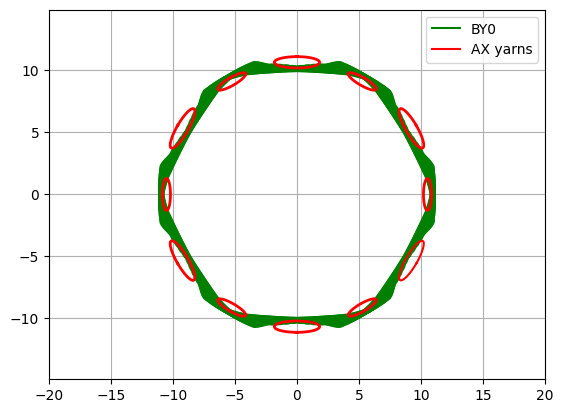

In [ ]:
k = 7
for j in range(169):
    x = globals()[f'braid_it_{k}'].filDict['BY'][0][j][:,0]
    y = globals()[f'braid_it_{k}'].filDict['BY'][0][j][:,1]
    if j == 168: 
        plt.plot(x,y,'green',label='BY0')
    else:
        plt.plot(x,y,'green')


for i in range(globals()[f'braid_it_{k}'].NYAX):
    x = globals()[f'braid_it_{k}'].filDict['AX'][i][0][:,0]
    y = globals()[f'braid_it_{k}'].filDict['AX'][i][0][:,1]
    if i == globals()[f'braid_it_{k}'].NYAX-1:
        plt.plot(x,y,'r',label='AX yarns')
    else:
        plt.plot(x,y,'r',linewidth=2)

# x = tresse_initiale.filDict['BY'][0][0][:,0]
# y = tresse_initiale.filDict['BY'][0][0][:,1]
# plt.plot(x,y,'r')

plt.axis('equal')
plt.grid()
plt.xlim([-20,20])
plt.ylim([-20,20])
plt.legend()
plt.show()


### Find the BY MID between AX yarns

In [61]:
braid_num = 7
for ax_index in range(globals()[f'braid_it_{braid_num}'].NYAX):
    ax_pos = (globals()[f'braid_it_{braid_num}'].AX[ax_index]['X'],
              globals()[f'braid_it_{braid_num}'].AX[ax_index]['Y'])
    # plt.scatter(ax_pos[0],ax_pos[1],c='r',marker='x')
    pass 

by_x_matrix = np.zeros((len(globals()[f'braid_it_{braid_num}'].BY[0]['Z']),
                        globals()[f'braid_it_{braid_num}'].NYBY))

by_y_matrix = np.zeros((len(globals()[f'braid_it_{braid_num}'].BY[0]['Z']),
                        globals()[f'braid_it_{braid_num}'].NYBY))

by_angle_matrix = np.zeros((len(globals()[f'braid_it_{braid_num}'].BY[0]['Z']),
                        globals()[f'braid_it_{braid_num}'].NYBY))

by_HGPos_matrix = np.zeros((len(globals()[f'braid_it_{braid_num}'].BY[0]['Z']),
                        globals()[f'braid_it_{braid_num}'].NYBY))

aby_matrix = np.zeros((len(globals()[f'braid_it_{braid_num}'].BY[0]['YARNa']),
                        globals()[f'braid_it_{braid_num}'].NYBY))

bby_matrix = np.zeros((len(globals()[f'braid_it_{braid_num}'].BY[0]['YARNb']),
                        globals()[f'braid_it_{braid_num}'].NYBY))



for by_num in range(globals()[f'braid_it_{braid_num}'].NYBY):
    by_x_matrix[:,by_num] = globals()[f'braid_it_{braid_num}'].BY[by_num]['X']
    by_y_matrix[:,by_num] = globals()[f'braid_it_{braid_num}'].BY[by_num]['Y']
    by_angle_matrix[:,by_num] = np.arctan2(globals()[f'braid_it_{braid_num}'].BY[by_num]['Y'],
                                           globals()[f'braid_it_{braid_num}'].BY[by_num]['X'])
    by_HGPos_matrix[:,by_num][np.array([globals()[f'braid_it_{braid_num}'].BY[by_num]['HGPos']]).\
                              reshape(len(globals()[f'braid_it_{braid_num}'].BY[by_num]['HGPos'])) == 'MID'] = 1
    aby_matrix[:,by_num] = globals()[f'braid_it_{braid_num}'].BY[by_num]['YARNa']
    bby_matrix[:,by_num] = globals()[f'braid_it_{braid_num}'].BY[by_num]['YARNb']
    # plt.scatter(by_x_matrix[:,by_num],by_y_matrix[:,by_num],marker='*',label=f'BY {by_num}')
    pass

by_angle_matrix[by_angle_matrix < 0] += 2*np.pi

yarns_dimensions = []
for i in range(globals()[f'braid_it_{braid_num}'].NYAX):
    try:
        borns = np.array([globals()[f'braid_it_{braid_num}'].AX[i]['phi'],
                        globals()[f'braid_it_{braid_num}'].AX[i+1]['phi']])
    except:
        borns = np.array([globals()[f'braid_it_{braid_num}'].AX[i]['phi'],
                        globals()[f'braid_it_{braid_num}'].AX[0]['phi'] + 2*np.pi])
    
    aby = np.mean(aby_matrix[(borns[0] < by_angle_matrix) & (by_angle_matrix < borns[1]) & (by_HGPos_matrix == 1)])
    bby = np.mean(bby_matrix[(borns[0] < by_angle_matrix) & (by_angle_matrix < borns[1]) & (by_HGPos_matrix == 1)])
    print('aby : ',aby)
    print('bby : ',bby,'\n')

# plt.axis('equal')
# plt.grid()
# plt.legend()
# plt.show()


aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 

aby :  3.3312754400701814
bby :  0.500891436464487 



In [8]:
by_HGPos_matrix[:,by_num]

array([0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0.,
       1., 0., 1., 0., 1., 0., 1.])

In [9]:
np.round(by_angle_matrix,1)

array([[0. , 0. , 1. , 1. , 2.1, 2.1, 3.1, 3.1, 4.2, 4.2, 5.2, 5.2],
       [0.2, 6.1, 1.3, 0.8, 2.3, 1.9, 3.4, 2.9, 4.4, 4. , 5.5, 5. ],
       [0.5, 5.8, 1.6, 0.5, 2.6, 1.6, 3.7, 2.6, 4.7, 3.7, 5.8, 4.7],
       [0.8, 5.5, 1.9, 0.2, 2.9, 1.3, 4. , 2.3, 5. , 3.4, 6.1, 4.4],
       [1. , 5.2, 2.1, 0. , 3.1, 1. , 4.2, 2.1, 5.2, 3.1, 0. , 4.2],
       [1.3, 5. , 2.3, 6.1, 3.4, 0.8, 4.4, 1.9, 5.5, 2.9, 0.2, 4. ],
       [1.6, 4.7, 2.6, 5.8, 3.7, 0.5, 4.7, 1.6, 5.8, 2.6, 0.5, 3.7],
       [1.9, 4.4, 2.9, 5.5, 4. , 0.2, 5. , 1.3, 6.1, 2.3, 0.8, 3.4],
       [2.1, 4.2, 3.1, 5.2, 4.2, 0. , 5.2, 1. , 0. , 2.1, 1. , 3.1],
       [2.3, 4. , 3.4, 5. , 4.4, 6.1, 5.5, 0.8, 0.2, 1.9, 1.3, 2.9],
       [2.6, 3.7, 3.7, 4.7, 4.7, 5.8, 5.8, 0.5, 0.5, 1.6, 1.6, 2.6],
       [2.9, 3.4, 4. , 4.4, 5. , 5.5, 6.1, 0.2, 0.8, 1.3, 1.9, 2.3],
       [3.1, 3.1, 4.2, 4.2, 5.2, 5.2, 0. , 0. , 1. , 1. , 2.1, 2.1],
       [3.4, 2.9, 4.4, 4. , 5.5, 5. , 0.2, 6.1, 1.3, 0.8, 2.3, 1.9],
       [3.7, 2.6, 4.7, 3.7, 5.8, 4

In [10]:
by_HGPos_matrix

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1.,

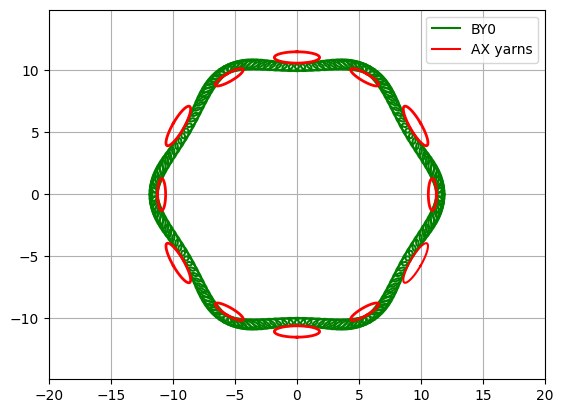

In [11]:
for j in range(169):
    x = tresse_initiale.filDict['BY'][0][j][:,0]
    y = tresse_initiale.filDict['BY'][0][j][:,1]
    if j == 168: 
        plt.plot(x,y,'green',label='BY0')
    else:
        plt.plot(x,y,'green')


for i in range(tresse_initiale.NYAX):
    x = tresse_initiale.filDict['AX'][i][0][:,0]
    y = tresse_initiale.filDict['AX'][i][0][:,1]
    if i == tresse_initiale.NYAX-1:
        plt.plot(x,y,'r',label='AX yarns')
    else:
        plt.plot(x,y,'r',linewidth=2)

# x = tresse_initiale.filDict['BY'][0][0][:,0]
# y = tresse_initiale.filDict['BY'][0][0][:,1]
# plt.plot(x,y,'r')

plt.axis('equal')
plt.grid()
plt.xlim([-20,20])
plt.ylim([-20,20])
plt.legend()
plt.show()


In [12]:
from prettytable import PrettyTable

mat = []
for i in range(tresse_initiale.NYBY):
    mat.append(np.array(tresse_initiale.BY[i]['HGPos']).reshape((2*tresse_initiale.NHG,1)))

res = np.hstack((mat[0],mat[1]))
for i in range(2,tresse_initiale.NYBY): 
    res = np.hstack((res,mat[i].reshape((2*tresse_initiale.NHG,1))))
header = []
for i in range(tresse_initiale.NYBY): 
    header.append(f'BY {i}')
t = PrettyTable(header)
for j in range(res.shape[0]):
    t.add_row(res[j,:])
print(t)

angle_table = PrettyTable(header)
for j in range(res.shape[0]):
    y = np.array([tresse_initiale.BY[i]['X'][j] for i in range(tresse_initiale.NYBY)])
    x = np.array([tresse_initiale.BY[i]['Y'][j] for i in range(tresse_initiale.NYBY)])
    angle = np.round(np.rad2deg(np.arctan2(x,y)))
    angle[angle< 0] += 360
    angle_table.add_row(angle)
# print(angle_table)

t2 = PrettyTable(header)
for j in range(res.shape[0]):
    row = np.array([round(tresse_initiale.BY[i]['YARNa'][j],3) for i in range(tresse_initiale.NYBY)])
    t2.add_row(row)
print(t2)

+------+------+------+------+------+------+------+------+------+------+-------+-------+
| BY 0 | BY 1 | BY 2 | BY 3 | BY 4 | BY 5 | BY 6 | BY 7 | BY 8 | BY 9 | BY 10 | BY 11 |
+------+------+------+------+------+------+------+------+------+------+-------+-------+
| OUT  |  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |  IN  |  OUT  |   IN  |
| MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  |  MID  |  MID  |
|  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |   IN  |  OUT  |
| MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  |  MID  |  MID  |
| OUT  |  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |  IN  |  OUT  |   IN  |
| MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  |  MID  |  MID  |
|  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |  IN  | OUT  |   IN  |  OUT  |
| MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  | MID  |  MID  |  MID  |
| OUT  |  IN  | OUT  |  IN  | OU

In [13]:
points = np.vstack((tresse_initiale.SplineDataStruct['BY'][0]['X'], tresse_initiale.SplineDataStruct['BY'][0]['Y'], tresse_initiale.SplineDataStruct['BY'][0]['Z']))
# Calcul des différences entre points consécutifs
diff = np.diff(points, axis=1)

# Calcul des distances euclidiennes entre points consécutifs
distances = np.sqrt(np.sum(diff**2, axis=0))

# Calcul de la longueur totale du fil
longueur_totale = np.sum(distances)

print("La longueur totale du fil est :", longueur_totale)


La longueur totale du fil est : 86.51897976188347


IndexError: invalid index to scalar variable.

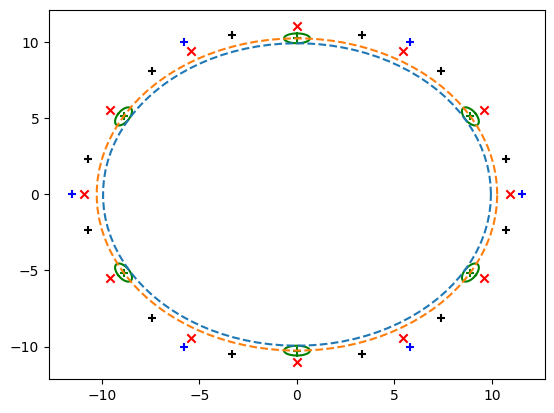

In [14]:
# AX 
xAX = np.array([tresse_initiale.AX[i]['X'] for i in range(tresse_initiale.NYAX)])
yAX = np.array([tresse_initiale.AX[i]['Y'] for i in range(tresse_initiale.NYAX)])
plt.scatter(xAX,yAX,color='r',label='AX',marker='x')

# BY IN 
index_BY_IN = [index for index, element in enumerate(tresse_initiale.BY[0]['HGPos']) if element == 'IN']
xBY = np.array([tresse_initiale.BY[0]['X'][i] for i in index_BY_IN])
yBY = np.array([tresse_initiale.BY[0]['Y'][i] for i in index_BY_IN])
plt.scatter(xBY,yBY,color='green',label='BY IN',marker='+')

n = tresse_initiale.NofInterpolPts
yarn = 0
index_BY_IN = [index for index, element in enumerate(tresse_initiale.BY[yarn]['HGPos']) if element == 'IN']
for j in index_BY_IN[0:len(index_BY_IN)-1]:
    plt.plot(tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,0], tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,1], color='green')
j = index_BY_IN[-1]
plt.plot(tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,0], tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,1], color='green',label='BY IN')


# BY MID 
index_BY_MID = [index for index, element in enumerate(tresse_initiale.BY[0]['HGPos']) if element == 'MID']
xBY = np.array([tresse_initiale.BY[0]['X'][i] for i in index_BY_MID])
yBY = np.array([tresse_initiale.BY[0]['Y'][i] for i in index_BY_MID])
plt.scatter(xBY,yBY,color='k',label='BY MID',marker='+')

# BY OUT
index_BY_OUT = [index for index, element in enumerate(tresse_initiale.BY[0]['HGPos']) if element == 'OUT']
xBY = np.array([tresse_initiale.BY[0]['X'][i] for i in index_BY_OUT])
yBY = np.array([tresse_initiale.BY[0]['Y'][i] for i in index_BY_OUT])
plt.scatter(xBY,yBY,color='blue',label='BY OUT',marker='+')

# Mandrel
plt.plot([tresse_initiale.MandrelDia/2*cos(t) for t in np.linspace(0,2*pi,100)],
         [tresse_initiale.MandrelDia/2*sin(t) for t in np.linspace(0,2*pi,100)],'--',label='Din')

# RBYIN
RBYIN = tresse_initiale.MandrelDia/2+tresse_initiale.BY[0]['YARNb'][0]/2
plt.plot([RBYIN*cos(t) for t in np.linspace(0,2*pi,100)],
         [RBYIN*sin(t) for t in np.linspace(0,2*pi,100)],'--')

# RBYMID
RBYMID = tresse_initiale.MandrelDia/2+tresse_initiale.BY[0]['YARNb'][0]+tresse_initiale.AX[0]['YARNb'][0]/2 
plt.plot([RBYMID*cos(t) for t in np.linspace(0,2*pi,100)],
         [RBYMID*sin(t) for t in np.linspace(0,2*pi,100)],'--')

# # RBYOUT
# RBYOUT = tresse_initiale.MandrelDia/2 + 1.5*tresse_initiale.BY[0]['YARNb'][0]+tresse_initiale.AX[0]['YARNb'][0]
# plt.plot([RBYOUT*cos(t) for t in np.linspace(0,2*pi,100)],
#          [RBYOUT*sin(t) for t in np.linspace(0,2*pi,100)],'--')

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

### Tresse initiale

In [ ]:
for i in range(tresse_initiale.NYAX):
    if i == tresse_initiale.NYAX-1: 
        plt.plot(tresse_initiale.filDict['AX'][i][0][:,0], tresse_initiale.filDict['AX'][i][0][:,1], 'r',label='AX yarns pre')
        # plt.plot([0,tresse_initiale.AX[i]['X']], [0,tresse_initiale.AX[i]['Y']], 'k', linewidth=1)
    else:
        plt.plot(tresse_initiale.filDict['AX'][i][0][:,0], tresse_initiale.filDict['AX'][i][0][:,1], 'r')
        # plt.plot([0,tresse_initiale.AX[i]['X']], [0,tresse_initiale.AX[i]['Y']], 'k', linewidth=1)

for i in range(tresse_opt.NYAX):
    if i == tresse_opt.NYAX-1: 
        plt.plot(tresse_opt.filDict['AX'][i][0][:,0], tresse_opt.filDict['AX'][i][0][:,1], 'orange',label='AX yarns opt')
    else:
        plt.plot(tresse_opt.filDict['AX'][i][0][:,0], tresse_opt.filDict['AX'][i][0][:,1], 'orange')

n = tresse_initiale.NofInterpolPts 
for yarn in [0]:
    for j in range(len(tresse_initiale.BY[0]['HGPos'])):
        plt.plot(tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,0], tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,1],color='k')


plt.axis('equal')
plt.grid()
plt.xlim([-20,20])
plt.ylim([-20,20])
plt.xlabel('x')
plt.ylabel('y')
plt.title("Tresse initiale")
plt.legend()

plt.show() 

In [ ]:
# braid1 = Braid(ReinfDensity=ReinfDensity,MatrixDensity=MatrixDensity,YarnCompaction=YarnCompaction,Pitch=Pitch,
#              Nslots=Nslots,MandrelPerimeter=MandrelPerimeter,NYBY=NYBY,NYAX=NYAX,NYCY=NYCY,aax=aax,
#              bax=bax,aby=aby,bby=bby,AYBY=AYBY,AYAX=AYAX,NofInterpolPts=6,smoothing=0,ByPoints=50,
#              MaxYarnRa=MaxYarnRa,MinYarnRa=MinYarnRa,NHG=NHG)
# braid1.__run__()
# braid2 = Braid(ReinfDensity=ReinfDensity,MatrixDensity=MatrixDensity,YarnCompaction=YarnCompaction,Pitch=Pitch,
#              Nslots=Nslots,MandrelPerimeter=MandrelPerimeter,NYBY=NYBY,NYAX=NYAX,NYCY=NYCY,aax=aax/4,
#              bax=bax/4,aby=aby,bby=bby,AYBY=AYBY,AYAX=AYAX,NofInterpolPts=6,smoothing=0,ByPoints=50,
#              MaxYarnRa=MaxYarnRa,MinYarnRa=MinYarnRa,NHG=NHG)
# braid2.__run__()

# for i in range(braid2.NYAX):
#     if i == braid2.NYAX-1: 
#         plt.plot(braid2.filDict['AX'][i][0][:,0], braid2.filDict['AX'][i][0][:,1], 'r',label='AX yarns')
#     else:
#         plt.plot(braid2.filDict['AX'][i][0][:,0], braid2.filDict['AX'][i][0][:,1], 'r')

# n = braid2.NofInterpolPts 
# for yarn in [0]:
#     for j in range(len(braid2.BY[0]['HGPos'])):
#         plt.plot(braid2.filDict['BY'][yarn][j*(n+1)][:,0], braid2.filDict['BY'][yarn][j*(n+1)][:,1],color='k')
    
# for yarn in [0]:
#     for j in range(len(braid1.BY[0]['HGPos'])):
#         plt.plot(braid1.filDict['BY'][yarn][j*(n+1)][:,0], braid1.filDict['BY'][yarn][j*(n+1)][:,1],color='b')

# plt.axis('equal')
# plt.grid()
# plt.xlim([-20,20])
# plt.ylim([-20,20])
# plt.xlabel('x')
# plt.ylabel('y')
# plt.legend()
# # plt.title("Tresse optimisée")

# plt.show() 

# # AX table 
# header1 = ['AX no',"phi init.[deg]","phi opt.[deg]"]
# t1 = PrettyTable()
# t1.add_column(fieldname="Ax no",column=range(braid1.NYAX),align="c")
# phi = np.array([round(np.rad2deg(np.arctan2(braid1.SplineDataStruct['AX'][i]['Y'][0],braid1.SplineDataStruct['AX'][i]['X'][0])),2) for i in range(braid1.NYAX)])
# phi[phi < 0] += 360
# t1.add_column(fieldname="Phi tresse init. [deg]",column=phi)
# phi = np.array([round(np.rad2deg(np.arctan2(tresse_opt.SplineDataStruct['AX'][i]['Y'][0],tresse_opt.SplineDataStruct['AX'][i]['X'][0])),2) for i in range(tresse_opt.NYAX)])
# phi[phi < 0] += 360
# t1.add_column(fieldname="Phi tresse opt. [deg]",column=phi)
# print(t1)

# # BY table
# for BY_nb in range(braid1.NYBY):
#     t = PrettyTable()
#     t.add_column(fieldname="z",column=np.round(braid1.BY[BY_nb]['Z'],2))
#     t.add_column(fieldname="HGPos",column=braid1.BY[BY_nb]['HGPos'])
#     phi = np.array([braid1.SplineDataStruct['BY'][BY_nb]['phi'][i*(n+1)] for i in range(len(braid1.BY[BY_nb]['HGPos']))])
#     phi = np.rad2deg(phi)
#     phi[phi < 0] += 360
#     phi = np.round(phi,2)
#     t.add_column(fieldname="Phi tresse init. [deg]",column=phi)
#     phi = np.array([tresse_opt.SplineDataStruct['BY'][BY_nb]['phi'][i*(n+1)] for i in range(len(tresse_opt.BY[BY_nb]['HGPos']))])
#     phi = np.rad2deg(phi)
#     phi[phi < 0] += 360
#     phi = np.round(phi,2)
#     t.add_column(fieldname="Phi tresse opt. [deg]",column=phi)
#     print(f"\nBY {BY_nb}\n{t}\n")


### Tresse optimisée

In [ ]:
for i in range(tresse_opt.NYAX):
    if i == tresse_opt.NYAX-1: 
        plt.plot(tresse_opt.filDict['AX'][i][0][:,0], tresse_opt.filDict['AX'][i][0][:,1], 'r',label='AX yarns')
    else:
        plt.plot(tresse_opt.filDict['AX'][i][0][:,0], tresse_opt.filDict['AX'][i][0][:,1], 'r')

n = tresse_opt.NofInterpolPts 
for yarn in [0]:
    for j in range(len(tresse_opt.BY[0]['HGPos'])):
        plt.plot(tresse_opt.filDict['BY'][yarn][j*(n+1)][:,0], tresse_opt.filDict['BY'][yarn][j*(n+1)][:,1],color='k')
    
for yarn in [0]:
    for j in range(len(tresse_initiale.BY[0]['HGPos'])):
        plt.plot(tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,0], tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,1],color='b')

plt.axis('equal')
plt.grid()
plt.xlim([-20,20])
plt.ylim([-20,20])
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title("Tresse optimisée")

plt.show() 

# AX table 
header1 = ['AX no',"phi init.[deg]","phi opt.[deg]"]
t1 = PrettyTable()
t1.add_column(fieldname="Ax no",column=range(tresse_opt.NYAX),align="c")
phi = np.array([round(np.rad2deg(np.arctan2(tresse_initiale.SplineDataStruct['AX'][i]['Y'][0],tresse_initiale.SplineDataStruct['AX'][i]['X'][0])),2) for i in range(tresse_opt.NYAX)])
phi[phi < 0] += 360
t1.add_column(fieldname="Phi tresse init. [deg]",column=phi)
phi = np.array([round(np.rad2deg(np.arctan2(tresse_opt.SplineDataStruct['AX'][i]['Y'][0],tresse_opt.SplineDataStruct['AX'][i]['X'][0])),2) for i in range(tresse_opt.NYAX)])
phi[phi < 0] += 360
t1.add_column(fieldname="Phi tresse opt. [deg]",column=phi)
print(t1)

# BY table
for BY_nb in range(tresse_initiale.NYBY):
    t = PrettyTable()
    t.add_column(fieldname="z",column=np.round(tresse_initiale.BY[BY_nb]['Z'],2))
    t.add_column(fieldname="HGPos",column=tresse_initiale.BY[BY_nb]['HGPos'])
    phi = np.array([tresse_initiale.SplineDataStruct['BY'][BY_nb]['phi'][i*(n+1)] for i in range(len(tresse_initiale.BY[BY_nb]['HGPos']))])
    phi = np.rad2deg(phi)
    phi[phi < 0] += 360
    phi = np.round(phi,2)
    t.add_column(fieldname="Phi tresse init. [deg]",column=phi)
    phi = np.array([tresse_opt.SplineDataStruct['BY'][BY_nb]['phi'][i*(n+1)] for i in range(len(tresse_opt.BY[BY_nb]['HGPos']))])
    phi = np.rad2deg(phi)
    phi[phi < 0] += 360
    phi = np.round(phi,2)
    t.add_column(fieldname="Phi tresse opt. [deg]",column=phi)
    print(f"\nBY {BY_nb}\n{t}\n")
# t1 = PrettyTable(header1)

# for i in range(tresse_opt.NYAX):
    # t1.add

In [ ]:

for yarn in [0]:
    z = tresse_initiale.SplineDataStruct['BY'][yarn]['Z']
    phi = np.rad2deg(tresse_initiale.SplineDataStruct['BY'][yarn]['phi'])
    theta = np.rad2deg(tresse_initiale.SplineDataStruct['BY'][yarn]['theta'])
    alpha = np.rad2deg(tresse_initiale.SplineDataStruct['BY'][yarn]['alpha'])
    phi[phi<0] += 360
    
    plt.plot(z,phi,label=r"Angle $\phi$ autour de l'axe $Z$")
    plt.plot(z,theta,label=r"Angle de tresse $\theta$ ")
    plt.plot(z,alpha,label=r"Angle de crimp $\alpha$ ")

plt.grid()
plt.ylabel(r'Angles de rotation [°]')
plt.xlabel(r'$z$')
plt.legend()
plt.title(r"Angles de rotation pour le fil de tresse 0 en degrés")
plt.savefig('rotation_angles_vs_pitch_yarn0.png',dpi=500)

# Plot mesh in terminal

In [ ]:
# import numpy as np
# import trimesh 

# path = 'STL_Files/it_0/it_0_BY_yarns.stl'
# meshFile = trimesh.load(path)
# meshFile.show()



In [ ]:
fid = mesh.Mesh.from_files(filenames=['STL_Files/it_0/it_0_BY_yarn_7.stl',\
                                      'STL_Files/it_0/it_0_BY_yarn_6.stl',\
                                      'STL_Files/it_0/it_0_AX_yarn_6.stl' ])
fid.save(f'test.stl')

In [ ]:
# We evaluate the dimensions of the MID yarns braid for all yarn 
            

                # for j in [index for index, element in enumerate(globals()[f'braid_it_{it-1}'].BY[yarn]['HGPos']) if element == 'MID']:
                #     # We compute the MID yarns 
                #     index_BY_IN = [index for index, element in enumerate(globals()[f'braid_it_{it-1}'].BY[yarn]['HGPos']) if element == 'IN']


                #     mean_BY_IN = np.mean(np.array([globals()[f'braid_it_{it-1}'].BY[yarn]['YARNb'][i] for i in index_BY_IN]))
                #     try : 
                #         HG_AX_index = [globals()[f'braid_it_{it-1}'].BY[yarn]['HG'][j],globals()[f'braid_it_{it-1}'].BY[yarn]['HG'][j+1]]
                #     except:
                #         HG_AX_index = [globals()[f'braid_it_{it-1}'].BY[yarn]['HG'][j],0]
                #     mean_AX = np.mean([globals()[f'braid_it_{it-1}'].AX[i]['YARNb'][0] for i in HG_AX_index])
                #     D_mid = Din + 2 * mean_BY_IN + mean_AX
                #     theta_MID=  atan((pi*D_mid)/globals()[f'braid_it_{it-1}'].Pitch)
                #     aby_new[j,yarn] = (globals()[f'braid_it_{it-1}'].Pitch/globals()[f'braid_it_{it-1}'].NYBY) * sin(theta_MID)
                #     bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                #     Ra = aby_new[j,yarn] /bby_new[j,yarn]

                #     if Ra > globals()[f'braid_it_{it-1}'].RaYBYmax : 
                #         aby_new[j,yarn] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYBY*globals()[f'braid_it_{it-1}'].RaYBYmax)/pi)
                #         bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                #     elif Ra < globals()[f'braid_it_{it-1}'].RaYBYmin: 
                #         aby_new[j,yarn] = np.sqrt((4*globals()[f'braid_it_{it-1}'].AYBY*globals()[f'braid_it_{it-1}'].RaYBYmin)/pi)
                #         bby_new[j,yarn] = 4 * globals()[f'braid_it_{it-1}'].AYBY/(pi*aby_new[j,yarn])
                #     Ra = aby_new[j,yarn] / bby_new[j,yarn]

In [ ]:
tresse_initiale.aax[0,0]

In [ ]:
for i in range(tresse_opt.NYAX):
    if i == tresse_opt.NYAX-1: 
        plt.plot(tresse_opt.filDict['AX'][i][0][:,0], tresse_opt.filDict['AX'][i][0][:,1], 'r',label='AX yarns pre')
    else:
        plt.plot(tresse_opt.filDict['AX'][i][0][:,0], tresse_opt.filDict['AX'][i][0][:,1], 'r')

for i in range(tresse_initiale.NYAX):
    if i == tresse_initiale.NYAX-1: 
        plt.plot(tresse_initiale.filDict['AX'][i][0][:,0], tresse_initiale.filDict['AX'][i][0][:,1], 'b',label='AX yarns opt')
    else:
        plt.plot(tresse_initiale.filDict['AX'][i][0][:,0], tresse_initiale.filDict['AX'][i][0][:,1], 'b')

# n = tresse_opt.NofInterpolPts 
# for yarn in [0]:
#     for j in range(len(tresse_opt.BY[0]['HGPos'])):
#         plt.plot(tresse_opt.filDict['BY'][yarn][j*(n+1)][:,0], tresse_opt.filDict['BY'][yarn][j*(n+1)][:,1],color='k')
    
# for yarn in [0]:
#     for j in range(len(tresse_initiale.BY[0]['HGPos'])):
#         plt.plot(tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,0], tresse_initiale.filDict['BY'][yarn][j*(n+1)][:,1],color='b')

plt.axis('equal')
plt.grid()
plt.xlim([-20,20])
plt.ylim([-20,20])
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title("Tresse optimisée")

plt.show() 
